.<center> 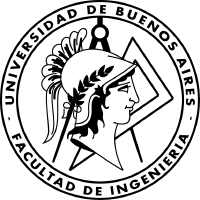



**Universidad de Buenos Aires**

**Facultad de Ingeniería**

**2do Cuatrimestre de 2025**

**Taller de Procesamiento de Señales**

---

**TP4: LDA, QDA y KNN**

**Alumno:** Lo Coco, Manuel - mlococo@fi.uba.ar - 103938 </center>

---


## (a) Exploración de datos


### (a.1)

Se carga el archivo *MulticlassDiabetesDataset.csv*. Esta base de datos contiene valores medidos de personas sin diabetes, con prediabetes y con diabetes. La idea del trabajo es poder predecir a partir de ciertos datos si una persona tiene diabetes o no.

In [211]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/mvera1412/TA136-TB056-TB057-8625/refs/heads/main/data/MulticlassDiabetesDataset.csv"
df=pd.read_csv(url)

print(df)

     Gender  AGE  Urea   Cr  HbA1c  Chol   TG  HDL  LDL  VLDL   BMI  Class
0         0   50   4.7   46    4.9   4.2  0.9  2.4  1.4   0.5  24.0      0
1         1   26   4.5   62    4.9   3.7  1.4  1.1  2.1   0.6  23.0      0
2         1   33   7.1   46    4.9   4.9  1.0  0.8  2.0   0.4  21.0      0
3         0   45   2.3   24    4.0   2.9  1.0  1.0  1.5   0.4  21.0      0
4         0   50   2.0   50    4.0   3.6  1.3  0.9  2.1   0.6  24.0      0
..      ...  ...   ...  ...    ...   ...  ...  ...  ...   ...   ...    ...
259       0   61  24.0  401    7.0   4.3  2.9  0.4  2.7   1.3  30.0      2
260       0   61  24.0  401    7.0   4.3  2.9  0.4  2.7   1.3  36.6      2
261       1   60  20.8  800    9.0   2.3  1.1  0.9  0.9   0.5  33.0      2
262       1   56  20.8  800    9.0   4.6  2.0  1.2  2.5   0.9  35.0      2
263       1   58  20.8  800    9.1   6.6  2.9  1.1  4.3   1.3  33.0      2

[264 rows x 12 columns]


### (a.2)

Cada columna de la base de datos representa una de estás características:
* Gender: Sexo biólogico del individuo: Hombre = 1, Mujer = 0
* Age: Edad del individuo en años
* Urea: Cantidad de urea en sangre (en $mg/dL$). Rango típico $\sim7-20\ mg/dL$
* Cr: Cantidad de creatinina en sangre (en $mg/dL$). Rango típico $\sim0.6-1.3\ mg/dL$
* HbA1c: Nivel promedio de glucosa en sangre durante los pasados 2-3 meses. Se expresa como porcentaje. Normal < 5.7%, Prediabético 5.7-6.4%, Diabético > 6.5%
* Chol: Colesterol en sangre (en $mg/dL$). Normal < 200 mg/dL
* TG: Cantidad de grasa en sangre (en $mg/dL$). Normal < 150 mg/dL
* HDL: El colesterol "bueno" (en $mg/dL$). Ideal: > 40 mg/dL en hombres, > 50 mg/dL en mujeres
* LDL: El colesterol "malo" (en $mg/dL$). Óptimo < 100 mg/dL
* VLDL: Otro tipo de colesterol "malo" (en $mg/dL$). Normal 2-30 mg/dL
* BMI: Medida de grasa del cuerpo basado en peso y altura (en $kg/m^2$).
  * Underweight: < 18.5
  * Normal: 18.5-24.9
  * Sobrepeso: 25 - 29.9
  * Obeso: > 30
* Class:
  * No-diabético: 0
  * Preddiabético: 1
  * Diabético: 2

### (a.3)

Se reportan la cantidad de muestras que hay de cada clase.

In [212]:
print("La cantidad de muestras para la clase 0[No diabético] es:", len(df[df["Class"] == 0]))
print("La cantidad de muestras para la clase 1[Pre diabético] es:", len(df[df["Class"] == 1]))
print("La cantidad de muestras para la clase 2[diabético] es:", len(df[df["Class"] == 2]))


La cantidad de muestras para la clase 0[No diabético] es: 96
La cantidad de muestras para la clase 1[Pre diabético] es: 40
La cantidad de muestras para la clase 2[diabético] es: 128


### (a.4)

Cada gráfico de un *pairplot* permite obsrvar la relación entre dos variables del dataset mediante un diagrama de dispersión. Esto es útil para identificar patrones de agrupamiento, tendencias lineales o no lineales, y posibles correlaciones entre las características. En las diagonales se representan los histogramas o distribuciones de cada variable de manera individual, lo que facilita comprender cómo se distribuyen sus valores y si presentan sesgos, dispersión amplia o concentraciones en determinados rangos.

En el gráfico del pairplot, particularmente en la relación HbA1c vs Clase, se observa que a partir de un determinado umbral de HbA1c los datos se separan claramente: los valores bajos corresponden casi en su totalidad a pacientes no diabéticos, mientras que los valores altos se asocian de manera consistente con pacientes diabéticos.

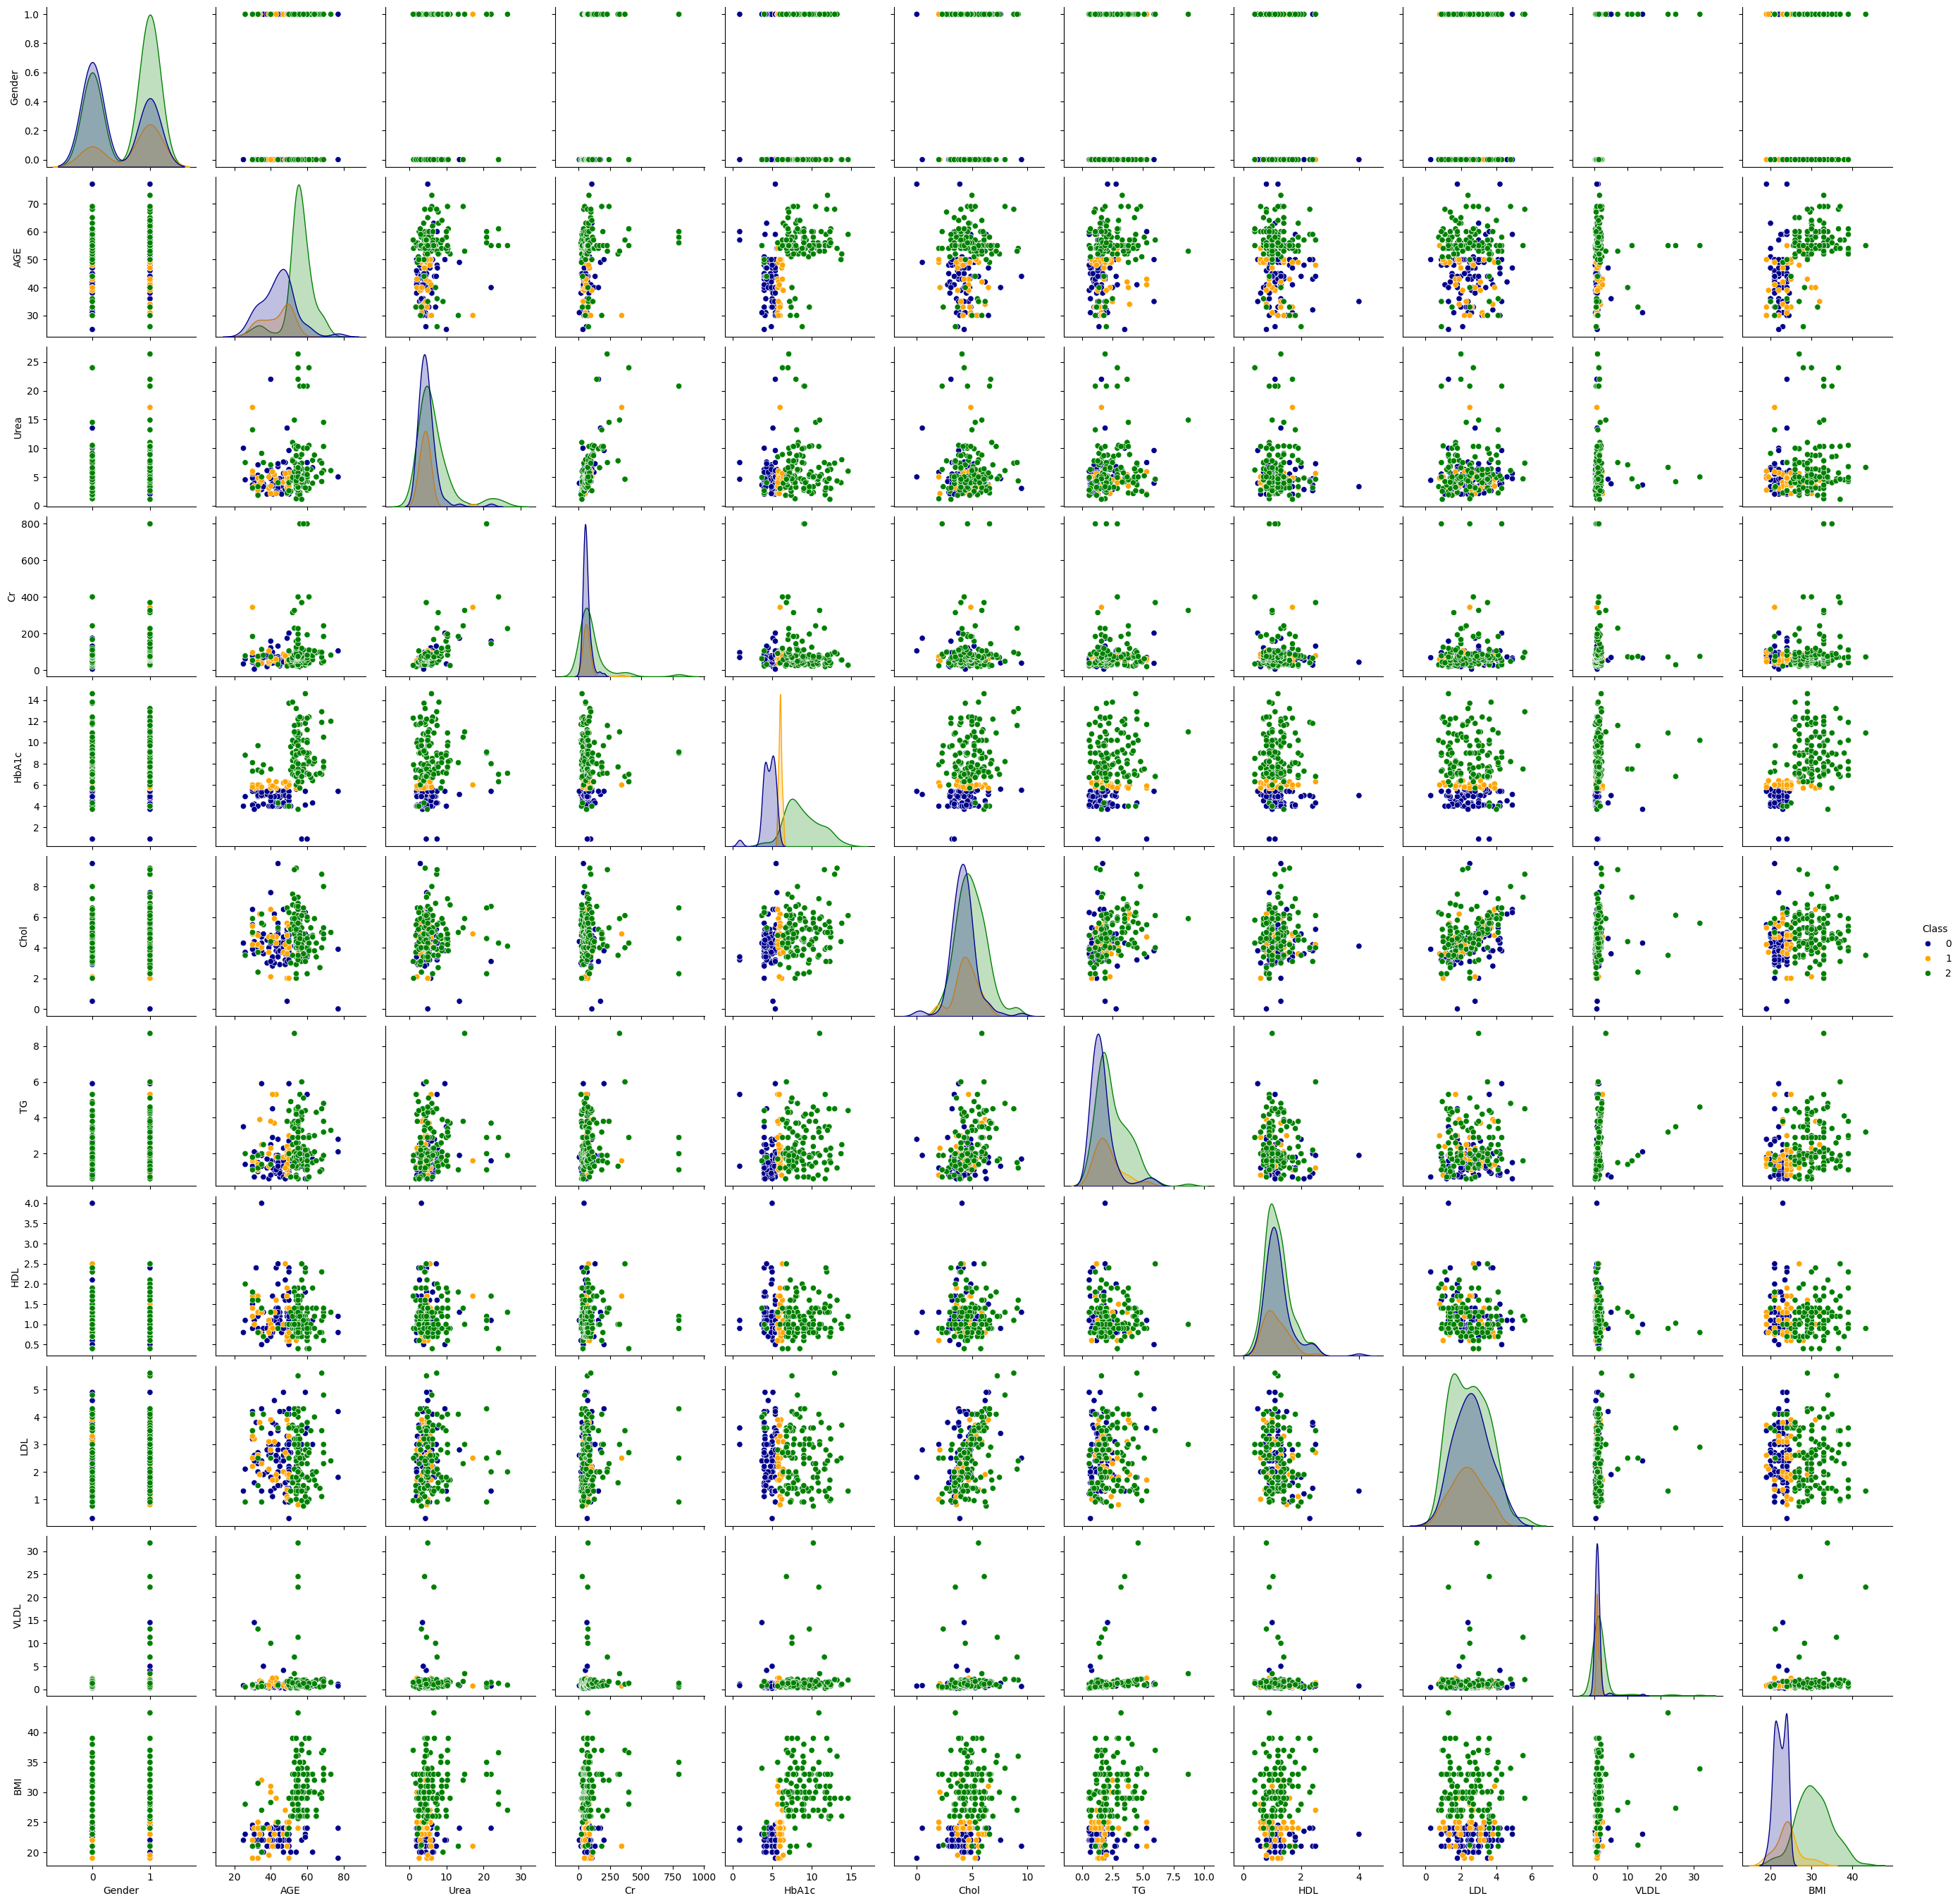

In [242]:
from seaborn import pairplot

custom_palette = {
    0: 'darkblue',
    1: 'orange',
    2: 'green'
}

pairplot(df, hue="Class", palette=custom_palette)

### (a.5)

Se separan la muestras con el comando *train_test_split* de *sklearn*. El conjunto de entrenamiento tiene el 80% de las muestras, mientras que el conjunto de testeo tiene el 20% restante. A su vez se separan distintos conjuntos que serán útiles a lo largo del trabajo.

In [214]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2, random_state=42)

X_train_HbA1c = train["HbA1c"].values.reshape(-1, 1)
X_train_HbA1c_BMI = train[["HbA1c", "BMI"]].values.reshape(-1, 2)
X_train_all = train.drop(columns=["Class"]).values.reshape(-1, 11)

X_test_HbA1c = test["HbA1c"].values.reshape(-1, 1)
X_test_HbA1c_BMI = test[["HbA1c", "BMI"]].values.reshape(-1, 2)
X_test_all = test.drop(columns=["Class"]).values.reshape(-1, 11)

y_train = train["Class"].values
y_test = test["Class"].values

## (b) Análisis de discriminante


El análisis de discriminante es una metodología de clasificación que opera modelando la distribución de las características X|Y=k, un concepto conocido como verosimilitud. El análisis de discriminante asume que esta distribución condicional de los datos es Gaussiana. Se asume que Y es una variable categórica tal que $Y\sim\text{cat}(c_1\cdots c_k)$

Las dos variantes más comunes del análisis de discriminante son LDA (lineal) y QDA (cuadrático). El modelo de verosimilitudd en LDA es:

$$X|Y=k\sim\mathcal{N}(\mu_k, \Sigma)$$

mientras que el modelo de verosimilitud en QDA es:

$$X|Y=k\sim\mathcal{N}(\mu_k, \Sigma_k)$$


A su vez, la tarea de clasificación se logra mediante la Función Discriminante $\delta_y(x)$ la cual es proporcional a la probabilidad logarítmica de que la observación x pertenezca a la clase y. En el caso de LDA, la función discriminante es lineal, mientras que en QDA es cuadrática.

### (b.1)

Se definen los subconjuntos de datos de cada clase k:
$$\mathcal{D}_k=\{x_i : 1 \leq i \leq n\ ∧\ y_i=k  \}$$

La proporción de cada clase k es:
$$c_k=\frac{\#(\mathcal{D}_k)}{n}$$

La media de la clase k se define como:

$$\mu_k = \frac{1}{\#(\mathcal{D}_k)}\sum_{x\in\mathcal{D}_k}x$$

La matriz de covarianza de la clase se k se calcula como:

$$\Sigma_k=\frac{1}{\#(\mathcal{D}_k)-1}\sum_{x\in\mathcal{D}_k}(x-\mu_k)(x-\mu_k)^T$$

La matriz de covarianza que se utiliza en LDA, donde se asume que todas las clases tienen la misma matriz de covarianza, es:
$$\Sigma=\frac{1}{n-k}\sum_{k=1}^{K}(\#(\mathcal{D}_k)-1)\Sigma_k$$

La función del discriminante para LDA se calcula como:

$$\delta_y(x)=\mu_y^T\Sigma^{-1}x-\frac{1}{2}\mu_y^T\Sigma^{-1}\mu_y+\log(c_y)$$

La función del discriminante para QDA se calcula como:
$$\delta_y(x)=-\frac{1}{2}(x-\mu_y)^T\Sigma_y^{-1}(x-\mu_y)+\log(c_y)-\frac{\log|\Sigma_y|}{2}$$

In [215]:
class LDA_QDA:
  # Inicializar atributos y declarar hiperparámetros.
  def __init__(self,LDA=False): #LDA selecciona entre LDA y QDA.
    self.classes = None
    self.LDA = LDA
    self.mu_k = {}      # media de cada clase
    self.sigma_k = {}   # matriz de covarianza de cada clase
    self.sigma = None   # matriz de covarianza única
    self.c_k = {}
    self.n = None       # cantidad de muestras
    self.len_k = None   # cantidad de clases

  # Etapa de entrenamiento. Calculo mu_k, sigma_k, sigma, c_k
  def fit(self,X,y):
    self.classes = np.unique(y)
    self.n = X.shape[0]
    self.len_k = len(self.classes)
    self.sigma = np.zeros((X.shape[1], X.shape[1]))

    for k in self.classes:
      D_k = X[y==k]
      # media cada clase
      self.mu_k[k] = np.mean(D_k, axis=0)
      # varianza cada clase
      self.sigma_k[k] = np.cov(D_k.T)

      self.c_k[k] = D_k.shape[0] / X.shape[0]
      self.sigma += (D_k.shape[0] - 1) * self.sigma_k[k]
    self.sigma /= (self.n - self.len_k)

  # Etapa de testeo hard
  def predict(self,X):
    delta = self.predict_discriminant(X)
    return self.classes[np.argmax(delta, axis=1)]

  #Etapa de testeo soft
  def predict_prob(self,X):
    delta = self.predict_discriminant(X)
    return np.exp(delta) / np.sum(np.exp(delta), axis=1, keepdims=True)

  def predict_discriminant(self,X):
    # largo total de datos de entrada
    n_samples = X.shape[0]
    # número de clases
    n_classes = len(self.classes)
    # creo una matriz para el discriminante
    discriminant = np.zeros((n_samples, n_classes))
    for i, k in enumerate(self.classes):
      mu = self.mu_k[k]
      sigma_y = self.sigma_k[k]
      c_k = self.c_k[k]
      if self.LDA:
        sigma_inv = np.linalg.pinv(self.sigma)
        discriminant[:,i] = X @ sigma_inv @ mu - 0.5 * mu.T @ sigma_inv @ mu + np.log(c_k)
      else: # caso QDA
        diff = X - mu
        if sigma_y.ndim == 0:
          sigma_y = sigma_y.reshape(1, 1)
        sigma_inv = np.linalg.pinv(sigma_y)
        log_det_sigma = np.log(np.linalg.det(sigma_y))

        # mahalanobis = (x-mu_y)^T sigma_y^(-1) (x-mu_y)
        if X.shape[1] == 1:
          mahalanobis = (diff[:, 0] * sigma_inv[0, 0] * diff[:, 0])
        else:
          mahalanobis = np.sum(diff @ sigma_inv * diff, axis=1)

        discriminant[:,i] =  - 0.5 * mahalanobis + np.log(c_k) - 0.5 * log_det_sigma
    return discriminant

### (b.2)

Se entrena al clasificador LDA y al QDA con el conjunto de datos de entrenamiento tomando solo la feature HbA1c.

In [216]:
clasifier_LDA_b2 = LDA_QDA(LDA=True)
clasifier_LDA_b2.fit(X_train_HbA1c, y_train)

clasifier_QDA_b2 = LDA_QDA(LDA=False)
clasifier_QDA_b2.fit(X_train_HbA1c, y_train)

### (b.3)

Se grafican las funciones discriminante para LDA y QDA en función de HbA1c.

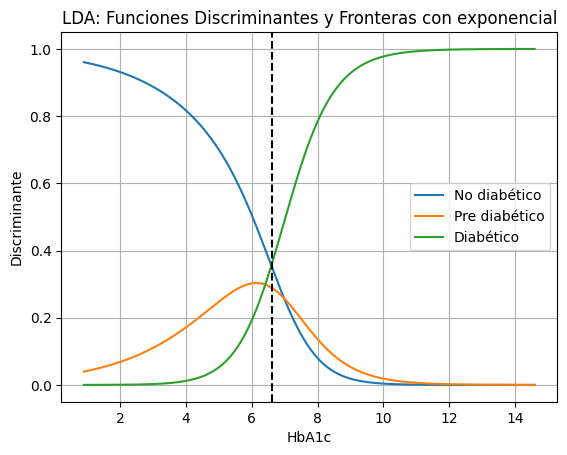

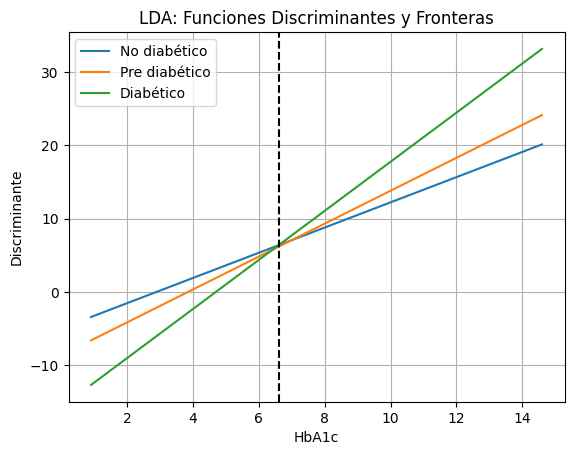

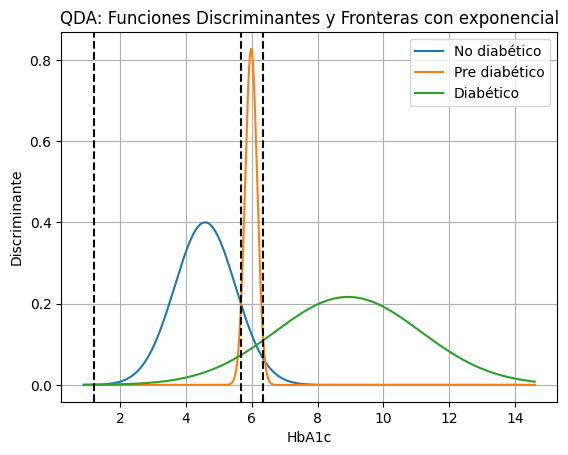

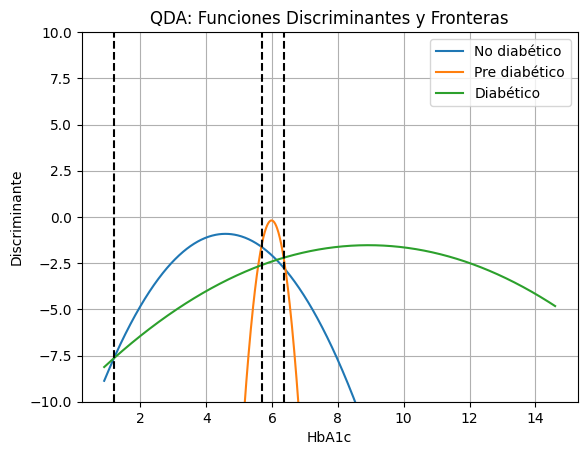

In [252]:
#Gráfico LDA
X_plot = np.linspace(X_train_HbA1c.min(), X_train_HbA1c.max(), 1000).reshape(-1, 1)
labels = ['No diabético', 'Pre diabético', 'Diabético']
discriminants_LDA = clasifier_LDA_b2.predict_prob(X_plot)
decision_map_LDA = np.argmax(discriminants_LDA, axis=1)
# grafico los discriminantes para cada clase
for i, label in enumerate(labels):
    plt.plot(X_plot, discriminants_LDA[:, i], label=label)
# grafico las fronteras de decisión
change_indices_LDA = np.where(np.diff(decision_map_LDA) != 0)[0]
if change_indices_LDA.size > 0:
    for idx in change_indices_LDA:
        cp = X_plot[idx + 1][0]
        plt.axvline(cp, color='k', linestyle='--', linewidth=1.5)
plt.legend()
plt.title('LDA: Funciones Discriminantes y Fronteras con exponencial')
plt.xlabel("HbA1c")
plt.ylabel("Discriminante")
plt.grid()
plt.show()

discriminants_LDA = clasifier_LDA_b2.predict_discriminant(X_plot)
# grafico los discriminantes para cada clase
for i, label in enumerate(labels):
    plt.plot(X_plot, discriminants_LDA[:, i], label=label)
# grafico las fronteras de decisión
change_indices_LDA = np.where(np.diff(decision_map_LDA) != 0)[0]
if change_indices_LDA.size > 0:
    for idx in change_indices_LDA:
        cp = X_plot[idx + 1][0]
        plt.axvline(cp, color='k', linestyle='--', linewidth=1.5)
plt.legend()
plt.title('LDA: Funciones Discriminantes y Fronteras')
plt.xlabel("HbA1c")
plt.ylabel("Discriminante")
plt.grid()
plt.show()

# Gráfico QDA
labels = ['No diabético', 'Pre diabético', 'Diabético']
discriminants_QDA = clasifier_QDA_b2.predict_discriminant(X_plot)
decision_map_QDA = np.argmax(discriminants_QDA, axis=1)
# grafico los discriminantes para cada clase
for i, label in enumerate(labels):
    plt.plot(X_plot, np.exp(discriminants_QDA[:, i]), label=label)
# grafico las fronteras de decisión
change_indices_QDA = np.where(np.diff(decision_map_QDA) != 0)[0]
if change_indices_QDA.size > 0:
    for idx in change_indices_QDA:
        cp = X_plot[idx + 1][0]
        plt.axvline(cp, color='k', linestyle='--', linewidth=1.5)

plt.legend()
plt.title('QDA: Funciones Discriminantes y Fronteras con exponencial')
plt.xlabel("HbA1c")
plt.ylabel("Discriminante")
plt.grid()
plt.show()


# grafico los discriminantes para cada clase
for i, label in enumerate(labels):
    plt.plot(X_plot, discriminants_QDA[:, i], label=label)
# grafico las fronteras de decisión
change_indices_QDA = np.where(np.diff(decision_map_QDA) != 0)[0]
if change_indices_QDA.size > 0:
    for idx in change_indices_QDA:
        cp = X_plot[idx + 1][0]
        plt.axvline(cp, color='k', linestyle='--', linewidth=1.5)

plt.legend()
plt.title('QDA: Funciones Discriminantes y Fronteras')
plt.xlabel("HbA1c")
plt.ylabel("Discriminante")
plt.ylim(-10, 10)
plt.grid()
plt.show()



A partir de los resultados obtenidos, se observa que en gráfico de LDA la curva correspondiente a la clase pre-diabético nunca logra superar a las de las demás categorías, manteniéndose siempre por debajo de ellas. La función
En cambio, en QDA, la función discriminante asociada al pre-diabético sí alcanza valores superiores a los de las clases diabético y no diabético en determinados rangos de HbA1c, lo que permite que el modelo pueda predecir correctamente dicha clase.

### (b.4)

A continuación se ve como se define una matriz de confusión. Donde en las filas se muestra el valor real y en la columnas el valor predicho.
$$
\begin{array}{|c|c|c|c|}
\hline
\text{Clase Real} \setminus \text{Clase Predicha} & \mathbf{0} \text{ (No Diabético)} & \mathbf{1} \text{ (Pre Diabético)} & \mathbf{2} \text{ (Diabético)} \\
\hline
\mathbf{0} \text{ (No Diabético)} & C_{0,0} & C_{0,1} & C_{0,2} \\
\hline
\mathbf{1} \text{ (Pre Diabético)} & C_{1,0} & C_{1,1} & C_{1,2} \\
\hline
\mathbf{2} \text{ (Diabético)} & C_{2,0} & C_{2,1} & C_{2,2} \\
\hline
\end{array}
$$


La accuracy se define como $\mathbb{P}(Y=\varphi(X))$ que en este caso se calcula como la suma de la diagonal de la matriz de confusión.



La métrica precision se calcula como:

$$\text{Precision}=\frac{TP}{TP+FP}$$

La métrica recall se calcula como:

$$\text{Recall}=\frac{TP}{TP+FN}$$

Donde para cada clase TP (verdaderos positivos) es el valor de la diagonal, FP (falsos positivos) es la suma de la columna sin el valor de la diagonal y FN (falsos negativos) es la suma de la fila sin el valor de la diagonal.


Se calcula la F1-score como:
$$F1-\text{score}=2\cdot\frac{\text{Precision}\cdot\text{Recall}}{\text{Precision}+\text{Recall}}$$

Y la Macro-F1 es el promedio de las métricas F1-score de cada clase.

In [218]:
def metrics(y_test, y_pred):
  n_classes = len(np.unique(y_test))
  Confusion_matrix = np.zeros((n_classes, n_classes))
  for i in range(len(y_test)):
      Confusion_matrix[y_test[i], int(y_pred[i])] += 1

  Accuracy = np.sum(np.diagonal(Confusion_matrix))/np.sum(Confusion_matrix)

  TP = np.zeros(n_classes, dtype=int)
  FN = np.zeros(n_classes, dtype=int)
  FP = np.zeros(n_classes, dtype=int)
  Precision = np.zeros(n_classes)
  Recall = np.zeros(n_classes)
  F1 = np.zeros(n_classes)

  for c in range(n_classes):
      # True positive es cada elemento de la diagonal
      TP[c] = Confusion_matrix[c, c]
      # False negative es la suma de la fila sin el valor de la diagonal
      FN[c] = np.sum(Confusion_matrix[c, :]) - TP[c]
      # False positive es la suma de la columna sin el valor de la diagonal
      FP[c] = np.sum(Confusion_matrix[:, c]) - TP[c]
      # Precision
      Precision[c] = TP[c] / (TP[c] + FP[c])
      # Recall
      Recall[c] = TP[c] / (TP[c] + FN[c])
      # F1
      F1[c] = 2 * Precision[c] * Recall[c] / (Precision[c] + Recall[c])
  macro_F1 = np.mean(F1)
  print("Matriz de confusión:\n", Confusion_matrix)
  print("accuracy: ", Accuracy)
  print("precision:", Precision)
  print("recall:   ", Recall)
  print("F1", F1)
  print("macro-F1: ", macro_F1)
  return Confusion_matrix, Accuracy, Precision, Recall, macro_F1, F1

In [219]:
y_pred_LDA_b4 = clasifier_LDA_b2.predict(X_test_HbA1c)
y_pred_QDA_b4 = clasifier_QDA_b2.predict(X_test_HbA1c)

print("LDA\n")
metrics(y_test, y_pred_LDA_b4);
print("\nQDA\n")
metrics(y_test, y_pred_QDA_b4);


LDA

Matriz de confusión:
 [[18.  0.  0.]
 [ 8.  0.  0.]
 [ 3.  0. 24.]]
accuracy:  0.7924528301886793
precision: [0.62068966        nan 1.        ]
recall:    [1.         0.         0.88888889]
F1 [0.76595745        nan 0.94117647]
macro-F1:  nan

QDA

Matriz de confusión:
 [[18.  0.  0.]
 [ 0.  6.  2.]
 [ 1.  1. 25.]]
accuracy:  0.9245283018867925
precision: [0.94736842 0.85714286 0.92592593]
recall:    [1.         0.75       0.92592593]
F1 [0.97297297 0.8        0.92592593]
macro-F1:  0.8996329662996331


/tmp/ipython-input-3399971241.py:24: RuntimeWarning: invalid value encountered in scalar divide
  Precision[c] = TP[c] / (TP[c] + FP[c])


Al analizar los resultados se observa una diferencia significativa entre las métricas de accuracy y F1 en el caso de LDA. Aunque el modelo alcanza un accuracy aceptable (≈0.79), este valor es engañoso, ya que se debe principalmente a la correcta clasificación de las clases mayoritarias (no diabético y diabético). Sin embargo, la clase pre-diabético nunca es detectada, lo que provoca que sus métricas de precisión, recall y F1 sean nulas o indefinidas. Esto explica por qué el macro-F1 resulta muy bajo en comparación con el accuracy: mientras el accuracy mide el porcentaje global de aciertos, el F1 macro penaliza fuertemente el hecho de que una clase quede completamente sin reconocer.

En cambio, con QDA el desempeño mejora considerablemente. El modelo logra clasificar correctamente instancias de las tres clases, incluyendo a los pre-diabéticos, aunque con algunos errores residuales. Esto se refleja en que tanto el accuracy (≈0.92) como el macro-F1 (≈0.90) muestran valores altos y coherentes, lo que indica un rendimiento más balanceado.

### (b.5)


Se grafican las funciones discriminante para LDA y QDA en función de HbA1c y BMI.

In [220]:
clasifier_LDA_b5 = LDA_QDA(LDA=True)
clasifier_LDA_b5.fit(X_train_HbA1c_BMI, y_train)

clasifier_QDA_b5 = LDA_QDA(LDA=False)
clasifier_QDA_b5.fit(X_train_HbA1c_BMI, y_train)

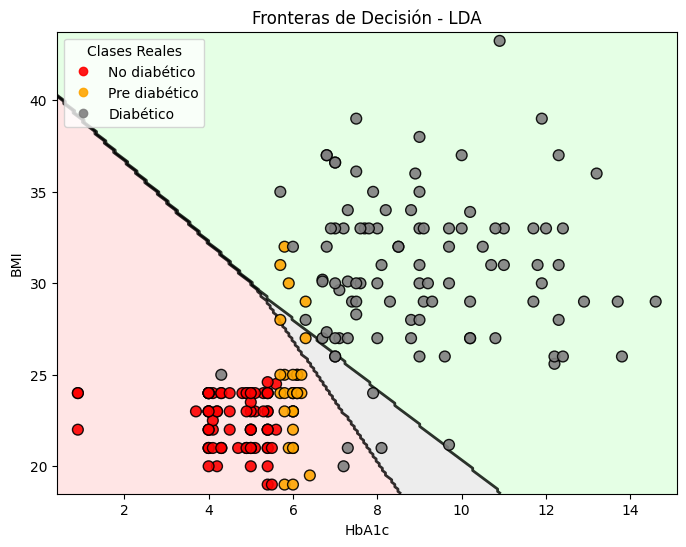

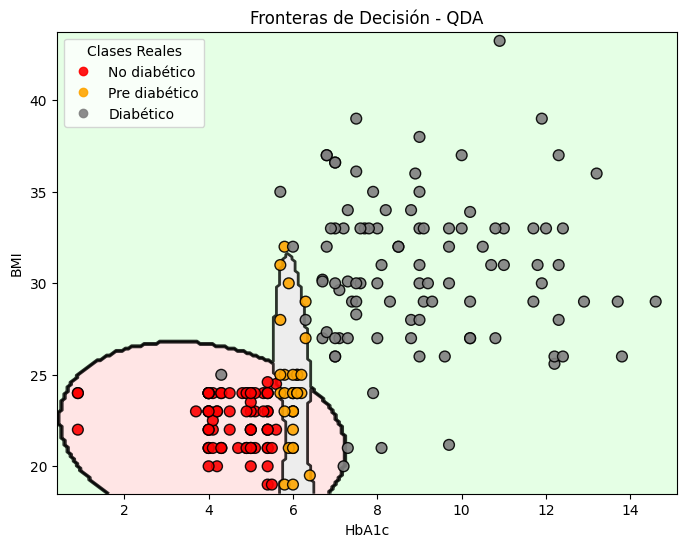

In [221]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap # Para mapear colores a clases específicas

def plot_decision_boundary_improved(clf, X, y, title, class_names):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid_points = np.c_[xx.ravel(), yy.ravel()]

    Z = clf.predict(grid_points)
    Z = Z.reshape(xx.shape)

    cmap_background = ListedColormap(['#FFCCCC', '#DDDDDD', '#CCFFCC'])
    cmap_points = ListedColormap(['red', 'orange', 'gray'])

    plt.figure(figsize=(8, 6))

    plt.contourf(xx, yy, Z, alpha=0.5, cmap=cmap_background)
    plt.contour(xx, yy, Z, levels=np.arange(Z.max() + 1) - 0.5,linewidths=2, colors='k', linestyles='-', alpha=0.8)
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=cmap_points, s=60, alpha=0.9, zorder=2)

    handles, _ = scatter.legend_elements()
    plt.legend(handles, class_names, title="Clases Reales", loc="upper left")

    plt.xlabel("HbA1c")
    plt.ylabel("BMI")
    plt.title(title)
    plt.show()

class_names = ['No diabético', 'Pre diabético', 'Diabético']


plot_decision_boundary_improved(clasifier_LDA_b5, X_train_HbA1c_BMI, y_train, "Fronteras de Decisión - LDA", class_names)
plot_decision_boundary_improved(clasifier_QDA_b5, X_train_HbA1c_BMI, y_train, "Fronteras de Decisión - QDA", class_names)

In [222]:
print("LDA\n")
y_pred_LDA_b5 = clasifier_LDA_b5.predict(X_test_HbA1c_BMI)
metrics(y_test, y_pred_LDA_b5);

print("\nQDA\n")
y_pred_QDA_b5 = clasifier_QDA_b5.predict(X_test_HbA1c_BMI)
metrics(y_test, y_pred_QDA_b5);

LDA

Matriz de confusión:
 [[18.  0.  0.]
 [ 8.  0.  0.]
 [ 0.  0. 27.]]
accuracy:  0.8490566037735849
precision: [0.69230769        nan 1.        ]
recall:    [1. 0. 1.]
F1 [0.81818182        nan 1.        ]
macro-F1:  nan

QDA

Matriz de confusión:
 [[18.  0.  0.]
 [ 1.  7.  0.]
 [ 0.  0. 27.]]
accuracy:  0.9811320754716981
precision: [0.94736842 1.         1.        ]
recall:    [1.    0.875 1.   ]
F1 [0.97297297 0.93333333 1.        ]
macro-F1:  0.9687687687687688


/tmp/ipython-input-3399971241.py:24: RuntimeWarning: invalid value encountered in scalar divide
  Precision[c] = TP[c] / (TP[c] + FP[c])


Se observa claramente que al incorporar la feature de BMI se mejora el rendimiento del modelo. Esto se refleja en el gráfico, donde puede apreciarse que los individuos con diabetes suelen presentar un BMI más elevado en comparación con aquellos que no la padecen, lo que facilita la separación entre clases. Asimismo, las métricas muestran una mejora respecto al caso en el que se utilizó únicamente la variable HbA1c. Por otro lado, también se confirma que el modelo QDA ofrece un mejor desempeño que LDA, ya que este último prácticamente ignora a la clase correspondiente a prediabetes, reduciendo su capacidad de discriminación en ese escenario.

### (b.6)

In [223]:
classifier_LDA_b6 = LDA_QDA(LDA=True)
classifier_LDA_b6.fit(X_train_all, y_train)
y_pred_LDA_b6 = classifier_LDA_b6.predict(X_test_all)

classifier_QDA_b6 = LDA_QDA(LDA=False)
classifier_QDA_b6.fit(X_train_all, y_train)
y_pred_QDA_b6 = classifier_QDA_b6.predict(X_test_all)

print("LDA\n")
metrics(y_test, y_pred_LDA_b6);

print("\nQDA\n")
metrics(y_test, y_pred_QDA_b6);

LDA

Matriz de confusión:
 [[17.  1.  0.]
 [ 7.  1.  0.]
 [ 0.  0. 27.]]
accuracy:  0.8490566037735849
precision: [0.70833333 0.5        1.        ]
recall:    [0.94444444 0.125      1.        ]
F1 [0.80952381 0.2        1.        ]
macro-F1:  0.6698412698412698

QDA

Matriz de confusión:
 [[18.  0.  0.]
 [ 3.  5.  0.]
 [ 0.  1. 26.]]
accuracy:  0.9245283018867925
precision: [0.85714286 0.83333333 1.        ]
recall:    [1.         0.625      0.96296296]
F1 [0.92307692 0.71428571 0.98113208]
macro-F1:  0.8728315709447786


## (c) Vecinos más cercanos:

El algoritmo K-Nearest Neighbors (KNN) es un método supervisado de clasificación que se basa en la proximidad entre las muestras. La idea central es que la clase de un nuevo dato se determina observando a qué clases pertenecen sus k vecinos más cercanos en el conjunto de entrenamiento.

En la etapa de entrenamiento el modelo no construye una función explícita, sino que simplemente almacena los datos de entrada y sus etiquetas. Para clasificar un nuevo punto, se calcula la distancia euclídea con cada muestra de entrenamiento y se seleccionan los k vecinos más próximos.

$$d(x,x_i)=||x-x_i||_2=\sqrt{\sum_{j=1}^d(x_j-x_{ij})^2}$$

Existen dos formas de inferencia:

* En la predicción soft, el modelo asigna a cada clase una probabilidad proporcional a la frecuencia de aparición de esa clase entre los vecinos:
$$\hat{P}(y|x)=\text{soft}\max_{y\in\mathcal{Y}}\delta_y(x)$$

* En la predicción hard, se asigna directamente la clase mayoritaria entre ellos:
$$\varphi(x)=\text{arg}\max_{y\in\mathcal{Y}}\delta_y(x)$$

### (c.1)

In [224]:
class KNN:
    # Inicializar atributos y declarar hiperparámetros.
    def __init__(self,k):
        self.k = k
        self.X = None
        self.y = None
        self.classes = None

    # Etapa de entrenamiento.
    def fit(self,X,y):
        self.X = X
        self.y = y
        self.classes = np.unique(y)

    # Etapa de testeo soft
    def predict_proba(self,X):
        n_samples = X.shape[0]
        n_classes = len(self.classes)
        y_pred = np.zeros((n_samples, n_classes))
        for i in range(n_samples):
            distances = np.linalg.norm(self.X - X[i], axis=1)
            k_indices = np.argsort(distances)[:self.k]
            k_labels = self.y[k_indices]
            unique, counts = np.unique(k_labels, return_counts=True)
            for u, c in zip(unique, counts):
                idx = np.where(self.classes == u)[0][0]
                y_pred[i, idx] = c / self.k
        return y_pred

    # Etapa de testeo hard
    def predict(self,X):
        n_samples = X.shape[0]
        y_pred = np.zeros(n_samples)
        for i in range(n_samples):
            distances = np.linalg.norm(self.X - X[i], axis=1)
            k_indices = np.argsort(distances)[:self.k]
            k_labels = self.y[k_indices]
            unique, counts = np.unique(k_labels, return_counts=True)
            y_pred[i] = unique[np.argmax(counts)]
        return y_pred


### (c.2)

Se entrena al clasificador KNN de 9 vecinos con el conjunto de datos de entrenamiento que solo tiene en cuenta la variable HbA1c.

In [225]:
knn = KNN(k=9)
knn.fit(X_train_HbA1c, y_train)

### (c.3)

En este fragmento se construye una grilla de valores de la característica HbA1c dentro del rango observado en los datos de entrenamiento. Para cada uno de esos valores posibles, el modelo KNN calcula las probabilidades de pertenencia a cada clase mediante el método soft (predict_proba). De esta manera se obtiene, para cualquier valor de HbA1c, una estimación de $P(y=c|x)$, es decir, la probabilidad de que el paciente pertenezca a la clase c.

Posteriormente, estas probabilidades se representan gráficamente como funciones escalonadas a lo largo del eje de HbA1c. Cada curva corresponde a una clase distinta y muestra cómo varía la probabilidad de clasificación según el valor de HbA1c.

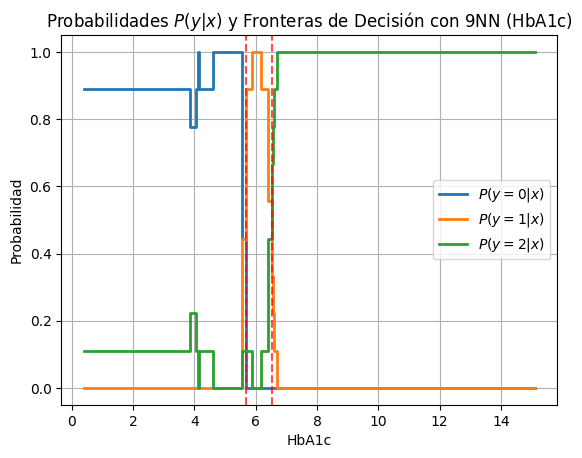

In [226]:

X_min, X_max = X_train_HbA1c.min() - 0.5, X_train_HbA1c.max() + 0.5
X_test = np.linspace(X_min, X_max, 500).reshape(-1, 1)

probs = knn.predict_proba(X_test)
classes = np.unique(y_train)

decision_map = np.argmax(probs, axis=1)
k = knn.k

boundaries_knn = []
change_indices = np.where(np.diff(decision_map) != 0)[0]
for i, cls in enumerate(classes):
    plt.step(X_test.flatten(), probs[:, i], where='post', label=f"$P(y={cls}|x)$", linewidth=2)

if change_indices.size > 0:
    for idx in change_indices:
        cp = X_test[idx + 1][0]
        boundaries_knn.append(cp)
        plt.axvline(cp, color='r', linestyle='--', linewidth=1.5, alpha=0.7)

plt.title(f'Probabilidades $P(y|x)$ y Fronteras de Decisión con {k}NN (HbA1c)')
plt.xlabel('HbA1c')
plt.ylabel('Probabilidad')
plt.legend()
plt.grid(True)
plt.show()

### (c.4)

In [227]:
y_pred_c4 = knn.predict(X_test_HbA1c)
metrics(y_test, y_pred_c4);

Matriz de confusión:
 [[18.  0.  0.]
 [ 0.  8.  0.]
 [ 1.  2. 24.]]
accuracy:  0.9433962264150944
precision: [0.94736842 0.8        1.        ]
recall:    [1.         1.         0.88888889]
F1 [0.97297297 0.88888889 0.94117647]
macro-F1:  0.9343461108166992


Los resultados obtenidos en los datos de testeo muestran que el modelo tiene un desempeño muy bueno, con una accuracy de 0.943, lo que indica que acierta la gran mayoría de las predicciones. La matriz de confusión evidencia que la mayoría de las instancias se clasificaron correctamente, con solo algunos errores en la clase 2. Finalmente, el macro-F1 de 0.934 refleja un buen equilibrio entre precisión y recall entre todas las clases, confirmando la eficacia general del modelo.

### (c.5)

In [228]:
knn_c5 = KNN(k=9)
knn_c5.fit(X_train_HbA1c_BMI, y_train)
y_pred_c5 = knn_c5.predict(X_test_HbA1c_BMI)
metrics(y_test, y_pred_c5);

Matriz de confusión:
 [[18.  0.  0.]
 [ 1.  7.  0.]
 [ 0.  0. 27.]]
accuracy:  0.9811320754716981
precision: [0.94736842 1.         1.        ]
recall:    [1.    0.875 1.   ]
F1 [0.97297297 0.93333333 1.        ]
macro-F1:  0.9687687687687688


El modelo muestra un desempeño excelente con una accuracy de 0.981, indicando que casi todas las predicciones fueron correctas. La matriz de confusión evidencia que solo hubo un error en la clase 1, mientras que las demás clases fueron clasificadas perfectamente. El macro-F1 cercano a 0.97 confirma un muy buen equilibrio entre precisión y recall entre todas las clases, destacando la efectividad del modelo al combinar las variables HbA1c y BMI.

### (c.6)

In [229]:
knn_c6 = KNN(k=9)
knn_c6.fit(X_train_all, y_train)
y_pred_c6 = knn_c6.predict(X_test_all)
metrics(y_test, y_pred_c6);


Matriz de confusión:
 [[15.  0.  3.]
 [ 5.  3.  0.]
 [ 1.  0. 26.]]
accuracy:  0.8301886792452831
precision: [0.71428571 1.         0.89655172]
recall:    [0.83333333 0.375      0.96296296]
F1 [0.76923077 0.54545455 0.92857143]
macro-F1:  0.7477522477522477


Al emplear todas las features disponibles, el modelo alcanzó un accuracy del 83%, mostrando un desempeño aceptable pero no óptimo. La matriz de confusión refleja que la clase 1 es la más conflictiva, ya que presenta varios errores de clasificación, mientras que la clase 2 mantiene un rendimiento muy alto. Esto se confirma con las métricas: la clase 1 obtuvo un F1 de 0.545, y la macro-F1 fue de 0.75 considerablemente inferior que en el punto anterior. Esto indica que incluir todas las variables no necesariamente mejora el modelo, e incluso puede introducir ruido o redundancia que dificulte la clasificación correcta.

## (d) Conclusiones


Al finalizar el trabajo se llegó a la conclusión de que resulta fundamental seleccionar adecuadamente las variables al momento de realizar una predicción. No siempre incorporar una mayor cantidad de variables garantiza un mejor rendimiento; por el contrario, en muchos casos es posible obtener resultados más precisos utilizando un número reducido de variables, lo que además disminuye la complejidad computacional.

La realización de este trabajo resultó muy enriquecedora, ya que permitió experimentar con distintos modelos de predicción y abrir la posibilidad de contar con múltiples enfoques para abordar problemas de predicción en el futuro.